<a href="https://colab.research.google.com/github/clheow/MachineLearning/blob/main/Prediksi_Keterlambatan_Penerbangan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd

In [17]:
# Load dataset
flights = pd.read_csv('/content/sample_data/flights.csv')
airlines = pd.read_csv('/content/sample_data/airlines.csv')
airports = pd.read_csv('/content/sample_data/airports.csv')

In [18]:
# =========================
# DATA UNDERSTANDING
# =========================

print("=== Statistik Deskriptif ===")
display(flights.describe())

print("\n=== Contoh Data ===")
display(flights.head())

print("\n=== Informasi Dataset (Tabel) ===")
info_df = pd.DataFrame({
    "Column": flights.columns,
    "Non-Null Count": flights.notnull().sum(),
    "Data Type": flights.dtypes
})

display(info_df)


=== Statistik Deskriptif ===


,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,113868.0,113868.0,113868.000000,113868.000000,113868.000000,113868.000000,111260.000000,111260.000000,111179.000000,111179.000000,...,113867.000000,111090.000000,110895.000000,113867.000000,113867.000000,38296.000000,38296.000000,38296.000000,38296.000000,38296.000000
mean,2015.0,1.0,4.166447,4.007201,2239.372791,1312.614483,1332.320304,19.321364,17.095764,1354.724912,...,1487.731590,1465.675011,17.471689,0.002266,0.023835,13.933231,0.070477,17.715375,25.816221,2.943127
std,0.0,0.0,2.066058,1.991053,1817.028283,482.935142,503.261936,45.274508,10.569924,503.878847,...,499.690637,537.912875,48.263255,0.047547,0.152535,25.935215,1.667479,43.094145,42.494481,18.005722
min,2015.0,1.0,1.000000,1.000000,1.000000,5.000000,1.000000,-39.000000,1.000000,1.000000,...,1.000000,1.000000,-65.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.0,1.0,2.000000,2.000000,755.000000,900.000000,909.000000,-3.000000,11.000000,926.000000,...,1100.000000,1050.000000,-8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2015.0,1.0,4.000000,4.000000,1693.000000,1310.000000,1327.000000,2.000000,14.000000,1340.000000,...,1510.000000,1506.000000,3.000000,0.000000,0.000000,4.000000,0.000000,4.000000,10.000000,0.000000
75%,2015.0,1.0,6.000000,6.000000,3402.250000,1721.000000,1741.000000,24.000000,20.000000,1756.000000,...,1912.000000,1917.000000,26.000000,0.000000,0.000000,19.000000,0.000000,19.000000,35.000000,0.000000
max,2015.0,1.0,8.000000,7.000000,7438.000000,2359.000000,2400.000000,1380.000000,176.000000,2400.000000,...,2359.000000,2400.000000,1384.000000,1.000000,1.000000,590.000000,107.000000,1380.000000,891.000000,681.000000



=== Contoh Data ===


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN



=== Informasi Dataset (Tabel) ===


,Column,Non-Null Count,Data Type
YEAR,YEAR,113868,int64
MONTH,MONTH,113868,int64
DAY,DAY,113868,int64
DAY_OF_WEEK,DAY_OF_WEEK,113868,int64
AIRLINE,AIRLINE,113868,object
FLIGHT_NUMBER,FLIGHT_NUMBER,113868,int64
TAIL_NUMBER,TAIL_NUMBER,113674,object
ORIGIN_AIRPORT,ORIGIN_AIRPORT,113868,object
DESTINATION_AIRPORT,DESTINATION_AIRPORT,113868,object
SCHEDULED_DEPARTURE,SCHEDULED_DEPARTURE,113868,int64


In [19]:
# =========================
# DATA PREPROCESSING - SAMPLING
# =========================

# Ambil 50000 data secara random
flights = flights.sample(n=50000, random_state=42)

print("Jumlah data setelah sampling:", flights.shape)

# =========================
# PILIH FITUR (LEBIH BANYAK)
# =========================
data = flights[[
 'AIRLINE',
 'ORIGIN_AIRPORT',
 'DESTINATION_AIRPORT',
 'DEPARTURE_DELAY',
 'DISTANCE',
 'AIR_TIME',
 'TAXI_OUT',
 'TAXI_IN',
 'SCHEDULED_DEPARTURE',
 'SCHEDULED_ARRIVAL',
 'DAY_OF_WEEK',
 'MONTH',
 'DAY',
 'ARRIVAL_DELAY'
]].copy()

# =========================
# HANDLE MISSING VALUE
# =========================
print("\nMissing values sebelum:")
print(data.isnull().sum())

data = data.dropna()

print("\nMissing values sesudah:")
print(data.isnull().sum())

# =========================
# OUTLIER HANDLING
# =========================
data['ARRIVAL_DELAY'] = data['ARRIVAL_DELAY'].clip(-100, 300)

# =========================
# UBAH SEMUA KE NUMERIC
# =========================
from sklearn.preprocessing import LabelEncoder
import pandas as pd

for col in data.columns:

    # coba ubah ke numeric dulu
    data[col] = pd.to_numeric(data[col], errors='ignore')

    # kalau masih object → encode
    if data[col].dtype == 'object':
        data[col] = data[col].astype(str).str.strip()

        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])

# =========================
# CEK HASIL
# =========================
print("\nTipe data setelah preprocessing:")
print(data.dtypes)

print("\nContoh data:")
print(data.head())

Jumlah data setelah sampling: (50000, 31)

Missing values sebelum:
AIRLINE                   0
ORIGIN_AIRPORT            0
DESTINATION_AIRPORT       0
DEPARTURE_DELAY        1173
DISTANCE                  1
AIR_TIME               1331
TAXI_OUT               1212
TAXI_IN                1245
SCHEDULED_DEPARTURE       0
SCHEDULED_ARRIVAL         1
DAY_OF_WEEK               0
MONTH                     0
DAY                       0
ARRIVAL_DELAY          1331
dtype: int64

Missing values sesudah:
AIRLINE                0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
DEPARTURE_DELAY        0
DISTANCE               0
AIR_TIME               0
TAXI_OUT               0
TAXI_IN                0
SCHEDULED_DEPARTURE    0
SCHEDULED_ARRIVAL      0
DAY_OF_WEEK            0
MONTH                  0
DAY                    0
ARRIVAL_DELAY          0
dtype: int64

Tipe data setelah preprocessing:
AIRLINE                  int64
ORIGIN_AIRPORT           int64
DESTINATION_AIRPORT      int64
DEPARTURE_DEL

/tmp/ipykernel_1775/1277623827.py:55: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data[col] = pd.to_numeric(data[col], errors='ignore')
/tmp/ipykernel_1775/1277623827.py:55: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data[col] = pd.to_numeric(data[col], errors='ignore')
/tmp/ipykernel_1775/1277623827.py:55: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data[col] = pd.to_numeric(data[col], errors='ignore')
/tmp/ipykernel_1775/1277623827.py:55: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data[col] = pd.to_numeric(data[col

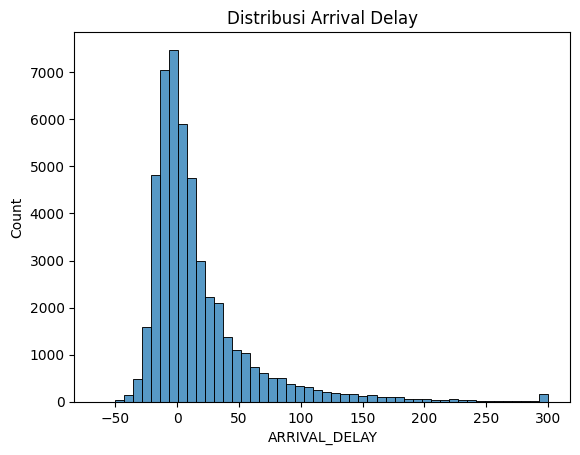

In [20]:
# =========================
# EDA (VISUALISASI)
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

# Distribusi delay
plt.figure()
sns.histplot(data['ARRIVAL_DELAY'], bins=50)
plt.title("Distribusi Arrival Delay")
plt.show()


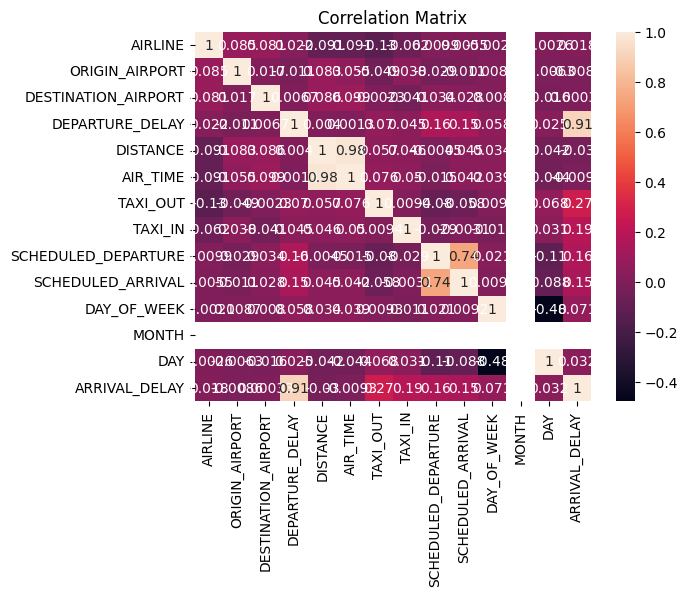

In [21]:
# Korelasi
plt.figure()
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

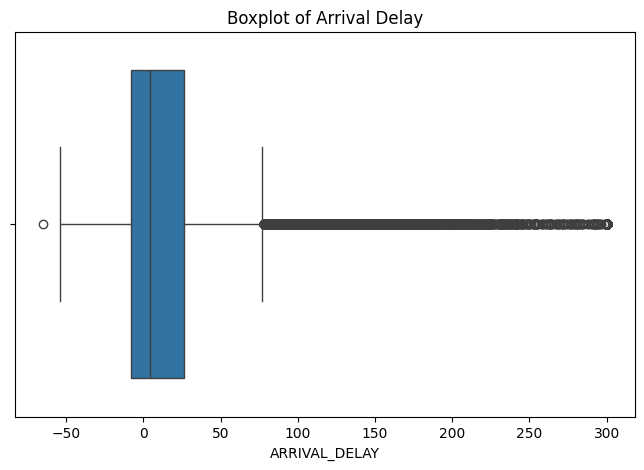

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=data['ARRIVAL_DELAY'])
plt.title("Boxplot of Arrival Delay")
plt.show()

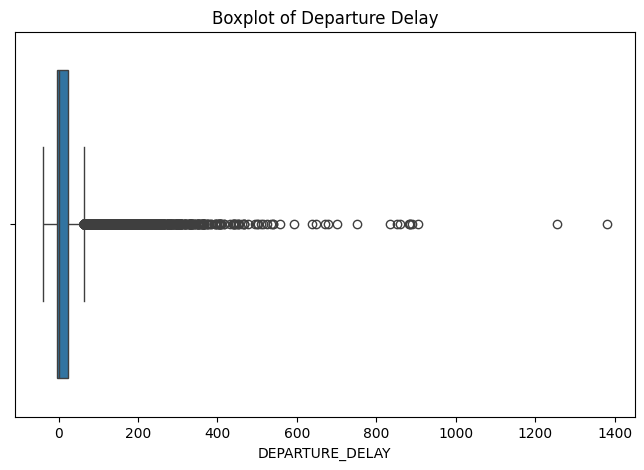

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data['DEPARTURE_DELAY'])
plt.title("Boxplot of Departure Delay")
plt.show()

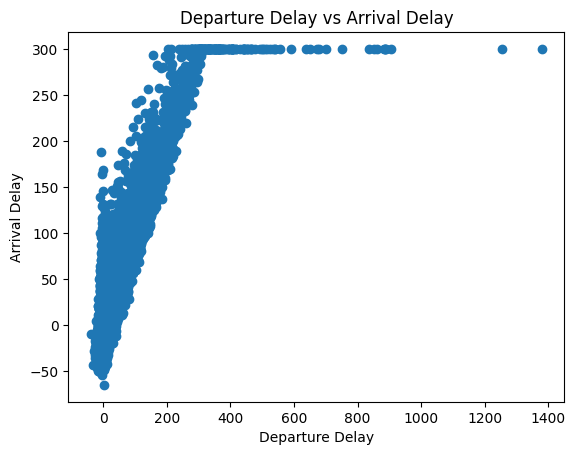

In [24]:
plt.figure()
plt.scatter(data['DEPARTURE_DELAY'], data['ARRIVAL_DELAY'])
plt.title("Departure Delay vs Arrival Delay")
plt.xlabel("Departure Delay")
plt.ylabel("Arrival Delay")
plt.show()

In [25]:
# =========================
# FEATURE & TARGET
# =========================
X = data.drop(columns=['ARRIVAL_DELAY'])
y = data['ARRIVAL_DELAY']

In [26]:
# =========================
# NORMALISASI
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [27]:
# =========================
# FUNCTION MODEL + TUNING + EVALUASI
# =========================

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    return r2

In [28]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

def run_experiment(test_size):

    print(f"\n==============================")
    print(f"SPLIT {int((1-test_size)*100)}:{int(test_size*100)}")
    print(f"==============================")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42)

    results = {}

    # =========================
    # 1. Gradient Boosting
    # =========================
    gb_params = {
        'n_estimators': [50,100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    }

    gb_grid = GridSearchCV(GradientBoostingRegressor(), gb_params, cv=2, n_jobs=-1)
    gb_grid.fit(X_train, y_train)

    print("Best GB Params:", gb_grid.best_params_)
    results["Gradient Boosting"] = evaluate_model(gb_grid.best_estimator_, X_test, y_test, "Gradient Boosting")

    # =========================
    # 2. KNN
    # =========================
    knn_params = {
        'n_neighbors': [3,5,7],
        'weights': ['uniform','distance']
    }

    knn_grid = GridSearchCV(KNeighborsRegressor(), knn_params, cv=2, n_jobs=-1)
    knn_grid.fit(X_train, y_train)

    print("Best KNN Params:", knn_grid.best_params_)
    results["KNN"] = evaluate_model(knn_grid.best_estimator_, X_test, y_test, "KNN")

    # =========================
    # 3. Random Forest
    # =========================
    rf_params = {
        'n_estimators': [50,100],
        'max_depth': [5, 10, None]
    }

    rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=2, n_jobs=-1)
    rf_grid.fit(X_train, y_train)

    print("Best RF Params:", rf_grid.best_params_)
    results["Random Forest"] = evaluate_model(rf_grid.best_estimator_, X_test, y_test, "Random Forest")

    return results

In [ ]:
# =========================
# Menjalankan data splitting
# =========================
results = []

results.append(run_experiment(0.3))  # 70:30
results.append(run_experiment(0.2))  # 80:20
results.append(run_experiment(0.1))  # 90:10


SPLIT 70:30
Best GB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

Gradient Boosting
MAE  : 6.2511
MSE  : 68.8713
RMSE : 8.2989
R2   : 0.9651
Best KNN Params: {'n_neighbors': 7, 'weights': 'distance'}

KNN
MAE  : 10.3572
MSE  : 193.3046
RMSE : 13.9034
R2   : 0.9021
Best RF Params: {'max_depth': None, 'n_estimators': 100}

Random Forest
MAE  : 6.9237
MSE  : 87.4264
RMSE : 9.3502
R2   : 0.9557

SPLIT 80:20
Best GB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

Gradient Boosting
MAE  : 6.2085
MSE  : 66.8586
RMSE : 8.1767
R2   : 0.9667
Best KNN Params: {'n_neighbors': 7, 'weights': 'distance'}

KNN
MAE  : 10.2175
MSE  : 187.2805
RMSE : 13.6850
R2   : 0.9067


In [ ]:
df_results = pd.DataFrame(results, index=["70:30","80:20","90:10"])

# ubah format
df_results = df_results.reset_index().rename(columns={"index": "Split"})

df_results = pd.melt(
    df_results,
    id_vars="Split",
    var_name="Model",
    value_name="Test R2"
)

print(df_results.head(9))

   Split              Model   Test R2
0  70:30  Gradient Boosting  0.946019
1  80:20  Gradient Boosting  0.946313
2  90:10  Gradient Boosting  0.946234
3  70:30                KNN  0.861130
4  80:20                KNN  0.863631
5  90:10                KNN  0.862890
6  70:30      Random Forest  0.936218
7  80:20      Random Forest  0.937433
8  90:10      Random Forest  0.937392


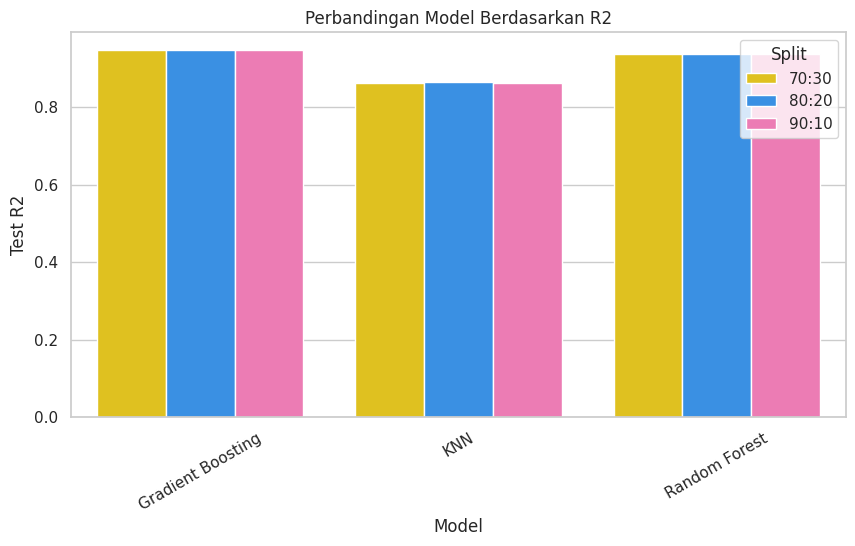

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_results,
    x="Model",
    y="Test R2",
    hue="Split",
    palette=["#FFD700", "#1E90FF", "#FF69B4"]
)

plt.title("Perbandingan Model Berdasarkan R2")
plt.xticks(rotation=30)

plt.show()